
--- 正在计算: Case 1 Exponential Growth ---


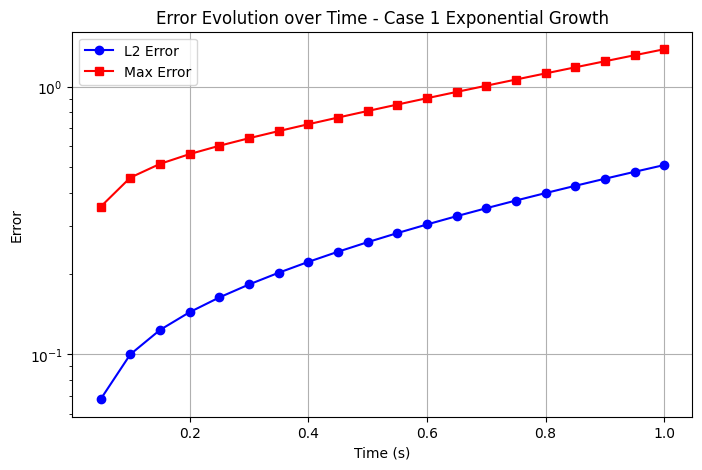

✅ 动画已保存为 heat_transfer_Case_1_Exponential_Growth.gif

--- 正在计算: Case 2 Decay ---


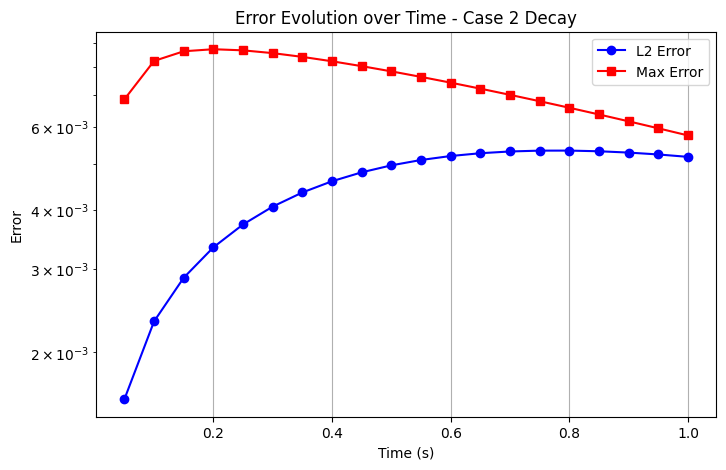

✅ 动画已保存为 heat_transfer_Case_2_Decay.gif

--- 正在计算: Case 3 Quadratic Time ---


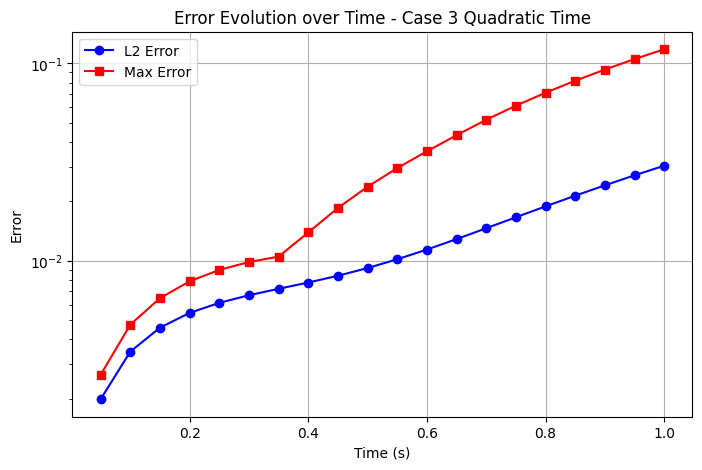

✅ 动画已保存为 heat_transfer_Case_3_Quadratic_Time.gif


In [4]:

import numpy as np
import gmsh
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import fem, mesh
from dolfinx.fem.petsc import assemble_matrix, assemble_vector, apply_lifting, set_bc
import dolfinx.io.gmsh as gmshio
import ufl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.animation import FuncAnimation

def solve_transient_heat(R, a_coef, u_func, ut_func, T_end, num_steps, case_name):
    print(f"\n--- 正在计算: {case_name} ---")
    
    # 1. 生成网格
    gmsh.initialize()
    model = gmsh.model()
    gmsh.option.setNumber("General.Terminal", 0)
    model.add("Disk")
    disk = model.occ.addDisk(0, 0, 0, R, R)
    model.occ.synchronize()
    model.addPhysicalGroup(2, [disk], 1)
    model.mesh.generate(2)
    mesh_data = gmshio.model_to_mesh(model, MPI.COMM_WORLD, 0, gdim=2)
    msh = mesh_data.mesh
    gmsh.finalize()

    V = fem.functionspace(msh, ("Lagrange", 1))
    x = ufl.SpatialCoordinate(msh)
    dt = T_end / num_steps
    t_val = fem.Constant(msh, 0.0)

    # 2. 构造制造解与源项
    u_e = u_func(x, t_val)
    u_t = ut_func(x, t_val)
    f = u_t - a_coef * ufl.div(ufl.grad(u_e))  
    n = ufl.FacetNormal(msh)
    g = ufl.dot(ufl.grad(u_e), n)

    # 3. 标记混合边界
    fdim = msh.topology.dim - 1
    left_facets = mesh.locate_entities_boundary(msh, fdim, lambda x: x[0] <= 1e-14)
    right_facets = mesh.locate_entities_boundary(msh, fdim, lambda x: x[0] >= -1e-14)
    indices = np.hstack([left_facets, right_facets])
    values = np.hstack([np.full_like(left_facets, 1), np.full_like(right_facets, 2)])
    order = np.argsort(indices)
    ft = mesh.meshtags(msh, fdim, indices[order], values[order])
    ds = ufl.Measure("ds", domain=msh, subdomain_data=ft)

    # 4. 初始条件 (t=0)
    u_n = fem.Function(V)
    u_n.interpolate(fem.Expression(u_e, V.element.interpolation_points))

    # 【修复点1】将 Dirichlet 边界框架移到循环外，并与矩阵 A 绑定
    u_dir = fem.Function(V)
    u_dir.interpolate(fem.Expression(u_e, V.element.interpolation_points))
    left_dofs = fem.locate_dofs_topological(V, fdim, left_facets)
    bc = fem.dirichletbc(u_dir, left_dofs)

    # 5. 弱形式 (Backward Euler)
    u, v = ufl.TrialFunction(V), ufl.TestFunction(V)
    a = u * v * ufl.dx + fem.Constant(msh, dt) * a_coef * ufl.dot(ufl.grad(u), ufl.grad(v)) * ufl.dx
    L = u_n * v * ufl.dx + fem.Constant(msh, dt) * f * v * ufl.dx + fem.Constant(msh, dt) * a_coef * g * v * ds(2)

    a_form = fem.form(a)
    L_form = fem.form(L)

    # 【修复核心】装配 A 时必须传入边界条件 bcs=[bc]
    A = assemble_matrix(a_form, bcs=[bc])
    A.assemble()
    solver = PETSc.KSP().create(msh.comm)
    solver.setOperators(A)
    solver.setType(PETSc.KSP.Type.PREONLY)
    solver.getPC().setType(PETSc.PC.Type.LU)

    uh = fem.Function(V)
    u_exact = fem.Function(V)
    
    times, l2_errors, max_errors = [], [], []
    frames_num, frames_exact = [], []

    # 6. 时间步进循环
    for n_step in range(1, num_steps + 1):
        t_val.value = n_step * dt
        
        # 只需要更新内部函数的值，外部绑定的 bc 会自动生效
        u_dir.interpolate(fem.Expression(u_e, V.element.interpolation_points))
        
        # 装配并求解 b
        b = assemble_vector(L_form)
        apply_lifting(b, [a_form], [[bc]])
        b.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
        set_bc(b, [bc])
        
        solver.solve(b, uh.x.petsc_vec)
        uh.x.scatter_forward()
        
        # 精确解
        u_exact.interpolate(fem.Expression(u_e, V.element.interpolation_points))
        
        # 计算误差
        diff = uh.x.array - u_exact.x.array
        err_L2 = np.sqrt(msh.comm.allreduce(fem.assemble_scalar(fem.form((uh - u_exact)**2 * ufl.dx)), op=MPI.SUM))
        err_max = np.max(np.abs(diff))
        
        # 使用纯数字 n_step * dt，打破数组引用
        times.append(n_step * dt)
        l2_errors.append(err_L2)
        max_errors.append(err_max)
        
        frames_num.append(uh.x.array.copy())
        frames_exact.append(u_exact.x.array.copy())
        
        u_n.x.array[:] = uh.x.array

    # 7. 绘制误差演化图
    plt.figure(figsize=(8, 5))
    plt.plot(times, l2_errors, 'b-o', label='L2 Error')
    plt.plot(times, max_errors, 'r-s', label='Max Error')
    plt.title(f"Error Evolution over Time - {case_name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Error")
    plt.yscale("log")
    plt.grid(True)
    plt.legend()
    plt.show()

    # 8. 生成 GIF
    coords = msh.geometry.x[:, :2]
    cells = msh.topology.connectivity(2, 0).array.reshape(-1, 3)
    tri = mtri.Triangulation(coords[:, 0], coords[:, 1], cells)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    c1 = axes[0].tripcolor(tri, frames_num[0], shading='flat', cmap='viridis')
    c2 = axes[1].tripcolor(tri, frames_exact[0], shading='flat', cmap='viridis')
    fig.colorbar(c1, ax=axes[0])
    fig.colorbar(c2, ax=axes[1])

    def update(frame_idx):
        axes[0].clear()
        axes[1].clear()
        axes[0].set_title(f"Numerical (t = {times[frame_idx]:.2f})")
        axes[1].set_title(f"Exact (t = {times[frame_idx]:.2f})")
        axes[0].set_aspect('equal')
        axes[1].set_aspect('equal')
        
        vmin = np.min(frames_exact[0])
        vmax = np.max(frames_exact[-1])
        tc1 = axes[0].tripcolor(tri, frames_num[frame_idx], shading='flat', cmap='viridis', vmin=vmin, vmax=vmax)
        tc2 = axes[1].tripcolor(tri, frames_exact[frame_idx], shading='flat', cmap='viridis', vmin=vmin, vmax=vmax)
        return tc1, tc2

    ani = FuncAnimation(fig, update, frames=len(times), blit=False)
    gif_name = f"heat_transfer_{case_name.replace(' ', '_')}.gif"
    ani.save(gif_name, writer='pillow', fps=5)
    print(f"✅ 动画已保存为 {gif_name}")
    plt.close()

# ==========================================
# 测试函数定义保持不变
# ==========================================
def u1(x, t): return (1.0 + x[0]**2 + 2.0*x[1]**2) * ufl.exp(t)
def ut1(x, t): return (1.0 + x[0]**2 + 2.0*x[1]**2) * ufl.exp(t)

def u2(x, t): return ufl.sin(x[0]) * ufl.cos(x[1]) * ufl.exp(-t)
def ut2(x, t): return -ufl.sin(x[0]) * ufl.cos(x[1]) * ufl.exp(-t)

def u3(x, t): return (x[0] + x[1]) * t**2
def ut3(x, t): return (x[0] + x[1]) * 2.0 * t

cases = [
    ("Case 1 Exponential Growth", u1, ut1),
    ("Case 2 Decay", u2, ut2),
    ("Case 3 Quadratic Time", u3, ut3)
]

for name, u_f, ut_f in cases:
    solve_transient_heat(1.0, 1.0, u_f, ut_f, 1.0, 20, name)